In [1]:
!pip install gym==0.23.1 pygame -q

In [2]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Librerias importadas correctamente')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Librerias importadas correctamente


# Actividad 3 – Aprendizaje por Refuerzo
## Entorno: FrozenLake 8×8
---
## 1. Exploración del Entorno

FrozenLake es una cuadrícula 8×8 donde el agente navega desde el inicio **S** (estado 0)
hasta la meta **G** (estado 63), evitando caer en hoyos **H**.

| Tile | Significado |
|------|-------------|
| S | Start – estado inicial (0) |
| F | Frozen – hielo libre, transitable |
| H | Hole – hoyo, estado terminal (R=0) |
| G | Goal – meta, estado terminal (R=1) |

**Propiedad clave:** `is_slippery=True` → con probabilidad 1/3 el agente se mueve
en la dirección deseada; con probabilidad 2/3 se desliza 90° (izquierda o derecha).

In [3]:
# gym >= 0.22 usa v1 (equivalente al v0 del profesor con is_slippery=True)
try:
    entorno = gym.make('FrozenLake8x8-v0')
except Exception:
    entorno = gym.make('FrozenLake8x8-v1', is_slippery=True)

nS = entorno.observation_space.n   # 64 estados
nA = entorno.action_space.n        # 4 acciones
P  = entorno.unwrapped.P           # función de transición

ACCIONES = {0: 'Izquierda', 1: 'Abajo', 2: 'Derecha', 3: 'Arriba'}
print(f'Numero de estados (nS): {nS}')
print(f'Numero de acciones (nA): {nA}')
print(f'Acciones: {ACCIONES}')

Numero de estados (nS): 64
Numero de acciones (nA): 4
Acciones: {0: 'Izquierda', 1: 'Abajo', 2: 'Derecha', 3: 'Arriba'}


In [4]:
# Mostrar el mapa del entorno
mapa = entorno.unwrapped.desc
print('Mapa FrozenLake 8x8 (S=Inicio, F=Hielo, H=Hoyo, G=Meta):')
print()
print('    Col: 0  1  2  3  4  5  6  7')
for i, fila in enumerate(mapa):
    tiles = '  '.join(c.decode() for c in fila)
    print(f'  Fila {i}: {tiles}')
print()
print(f'Estado 0  = S (inicio, esquina superior izquierda)')
print(f'Estado 63 = G (meta,   esquina inferior derecha)')
n_hoyos = sum(c.decode() == 'H' for fila in mapa for c in fila)
print(f'Total de hoyos: {n_hoyos}')

Mapa FrozenLake 8x8 (S=Inicio, F=Hielo, H=Hoyo, G=Meta):

    Col: 0  1  2  3  4  5  6  7
  Fila 0: S  F  F  F  F  F  F  F
  Fila 1: F  F  F  F  F  F  F  F
  Fila 2: F  F  F  H  F  F  F  F
  Fila 3: F  F  F  F  F  H  F  F
  Fila 4: F  F  F  H  F  F  F  F
  Fila 5: F  H  H  F  F  F  H  F
  Fila 6: F  H  F  F  H  F  H  F
  Fila 7: F  F  F  H  F  F  F  G

Estado 0  = S (inicio, esquina superior izquierda)
Estado 63 = G (meta,   esquina inferior derecha)
Total de hoyos: 10


In [24]:
# P[s][a] -> [(probabilidad, estado_siguiente, recompensa, terminal), ...]
print('Funcion de transicion: P[s][a] -> [(prob, s_nuevo, reward, done)]')
print()
print('Ejemplo A: estado 0 (S), accion 2 (Derecha):')
for prob, s_, r, done in P[0][2]:
    print(f'  -> estado {s_:2d} | prob={prob:.4f} | r={r} | done={done}')
print()
print('Ejemplo B: estado 62 (F, adyacente a meta), accion 2 (Derecha):')
for prob, s_, r, done in P[62][2]:
    print(f'  -> estado {s_:2d} | prob={prob:.4f} | r={r} | done={done}')
print()
print('Nota: cada accion genera exactamente 3 posibles transiciones (prob=1/3 c/u)')

Funcion de transicion: P[s][a] -> [(prob, s_nuevo, reward, done)]

Ejemplo A: estado 0 (S), accion 2 (Derecha):
  -> estado  8 | prob=0.3333 | r=0.0 | done=False
  -> estado  1 | prob=0.3333 | r=0.0 | done=False
  -> estado  0 | prob=0.3333 | r=0.0 | done=False

Ejemplo B: estado 62 (F, adyacente a meta), accion 2 (Derecha):
  -> estado 62 | prob=0.3333 | r=0.0 | done=False
  -> estado 63 | prob=0.3333 | r=1.0 | done=True
  -> estado 54 | prob=0.3333 | r=0.0 | done=True

Nota: cada accion genera exactamente 3 posibles transiciones (prob=1/3 c/u)


In [6]:
print('=' * 60)
print('  DEMOSTRACION DEL EFECTO DE DESLIZAMIENTO (Slipping Effect)')
print('=' * 60)
print()
print('Experimento: desde estado=0, accion=2 (Derecha), repetido 15 veces.')
print('Sin deslizamiento, siempre llegariamos al estado 1.')
print()

conteo = {}
for i in range(15):
    entorno.reset()                        # siempre regresa al estado 0
    s_, r, done, info = entorno.step(2)    # accion: Derecha
    conteo[s_] = conteo.get(s_, 0) + 1
    prob_real = list(info.values())[0] if info else 0.333
    print(f'  Intento {i+1:2d}: estado 0 + Derecha -> estado {s_:2d}  (prob={prob_real:.4f})')

print()
print('Frecuencia de estados alcanzados:')
for estado, veces in sorted(conteo.items()):
    print(f'  Estado {estado:2d}: {veces}/15 veces  ({veces/15:.0%})')
print()
print('Conclusion: misma accion, mismo estado -> resultados distintos.')
print('Esto es el deslizamiento estocastico propio de FrozenLake.')

  DEMOSTRACION DEL EFECTO DE DESLIZAMIENTO (Slipping Effect)

Experimento: desde estado=0, accion=2 (Derecha), repetido 15 veces.
Sin deslizamiento, siempre llegariamos al estado 1.

  Intento  1: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento  2: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento  3: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento  4: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  5: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  6: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento  7: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  8: estado 0 + Derecha -> estado  1  (prob=0.3333)
  Intento  9: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento 10: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento 11: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento 12: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento 13: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento 14: estado 0 +

### Análisis – Sección 1

**Estructura del MDP:**
- **64 estados** (cuadrícula 8×8, numerados fila × 8 + columna)
- **4 acciones**: Izquierda (0), Abajo (1), Derecha (2), Arriba (3)
- **Transiciones estocásticas**: prob 1/3 por cada una de las 3 direcciones posibles
- **Recompensa escasa**: R=0 en cada paso; R=1 únicamente al llegar al estado 63 (G)

**Efecto de deslizamiento:**
La demostración muestra que la misma acción desde el mismo estado puede llevar a
estados diferentes. Desde el estado 0 tomando "Derecha", el agente puede terminar en:
- Estado 1 (movimiento intencional, prob≈1/3)
- Estado 0 (desliza hacia arriba → choca pared, prob≈1/3)
- Estado 8 (desliza hacia abajo, prob≈1/3)

**Implicaciones para el aprendizaje:**
- **PD (model-based)**: puede usar P directamente para calcular la política óptima exacta.
- **MC (model-free)**: debe explorar el entorno, acumular episodios y aprender de la experiencia.
  Las recompensas escasas y los episodios largos dificultan la convergencia de MC.

---
## 2. Programación Dinámica (PD)

Métodos **model-based**: requieren conocer la función de transición P.
Resuelven el MDP exactamente usando las ecuaciones de Bellman.

### 2.1 Iteración de Política (PI)
Alterna entre *evaluación* (calcular V bajo la política actual) y
*mejora* (actualizar la política greedy respecto a V) hasta convergencia.

### 2.2 Iteración de Valores (VI)
Aplica directamente la ecuación de optimalidad de Bellman (barrido de V)
hasta que el cambio máximo δ < θ, luego extrae la política greedy.

In [7]:
GAMMA = 0.99    # factor de descuento
THETA = 1e-10   # criterio de convergencia

In [8]:
def calcular_funcion_q(P, nA, V, s, gamma=GAMMA):
    """Q(s,a) = sum_s' P(s'|s,a)[r + gamma*V(s')]"""
    q = np.zeros(nA)
    for a in range(nA):
        for prob, s_, r, done in P[s][a]:
            q[a] += prob * (r + gamma * V[s_])
    return q

def evaluacion_politica(P, nS, nA, politica, gamma=GAMMA, theta=THETA):
    """Evalua V bajo la politica dada; retorna V y lista de deltas por barrido."""
    V = np.zeros(nS)
    deltas = []
    while True:
        delta = 0
        for s in range(nS):
            Vs = 0
            for a, pr in enumerate(politica[s]):
                for prob, s_, r, done in P[s][a]:
                    Vs += pr * prob * (r + gamma * V[s_])
            delta = max(delta, abs(V[s] - Vs))
            V[s] = Vs
        deltas.append(delta)
        if delta < theta:
            break
    return V, deltas

def mejorar_politica(P, nS, nA, V, gamma=GAMMA):
    """Retorna la politica greedy respecto a V."""
    politica = np.zeros([nS, nA])
    for s in range(nS):
        q = calcular_funcion_q(P, nA, V, s, gamma)
        politica[s][np.argmax(q)] = 1
    return politica

In [9]:
def iterar_politica(P, nS, nA, gamma=GAMMA, theta=THETA):
    politica = np.ones([nS, nA]) / nA
    todos_deltas = []
    n_iter = 0
    while True:
        V, deltas = evaluacion_politica(P, nS, nA, politica, gamma, theta)
        todos_deltas.extend(deltas)
        politica_nueva = mejorar_politica(P, nS, nA, V, gamma)
        n_iter += 1
        if (politica_nueva == politica).all():
            break
        politica = np.copy(politica_nueva)
    print(f'PI: {n_iter} mejoras de politica | {len(todos_deltas)} barridos de evaluacion')
    return politica_nueva, V, todos_deltas

def iteracion_valores(P, nS, nA, gamma=GAMMA, theta=THETA):
    V = np.zeros(nS)
    deltas = []
    while True:
        delta = 0
        for s in range(nS):
            v = V[s]
            V[s] = max(calcular_funcion_q(P, nA, V, s, gamma))
            delta = max(delta, abs(V[s] - v))
        deltas.append(delta)
        if delta < theta:
            break
    politica = mejorar_politica(P, nS, nA, V, gamma)
    print(f'VI: {len(deltas)} barridos hasta convergencia')
    return politica, V, deltas

def evaluar_politica(entorno, politica, episodios=1000):
    """Tasa de exito de la politica greedy en N episodios."""
    exitos = 0
    for _ in range(episodios):
        s = entorno.reset()
        done = False
        while not done:
            a = np.argmax(politica[s])
            s, r, done, _ = entorno.step(a)
        if r == 1.0:
            exitos += 1
    return exitos / episodios

In [10]:
print('Ejecutando Iteracion de Politica (PI)...')
politica_pi, V_pi, deltas_pi = iterar_politica(P, nS, nA)

print()
print('Ejecutando Iteracion de Valores (VI)...')
politica_vi, V_vi, deltas_vi = iteracion_valores(P, nS, nA)

Ejecutando Iteracion de Politica (PI)...
PI: 3 mejoras de politica | 1210 barridos de evaluacion

Ejecutando Iteracion de Valores (VI)...
VI: 440 barridos hasta convergencia


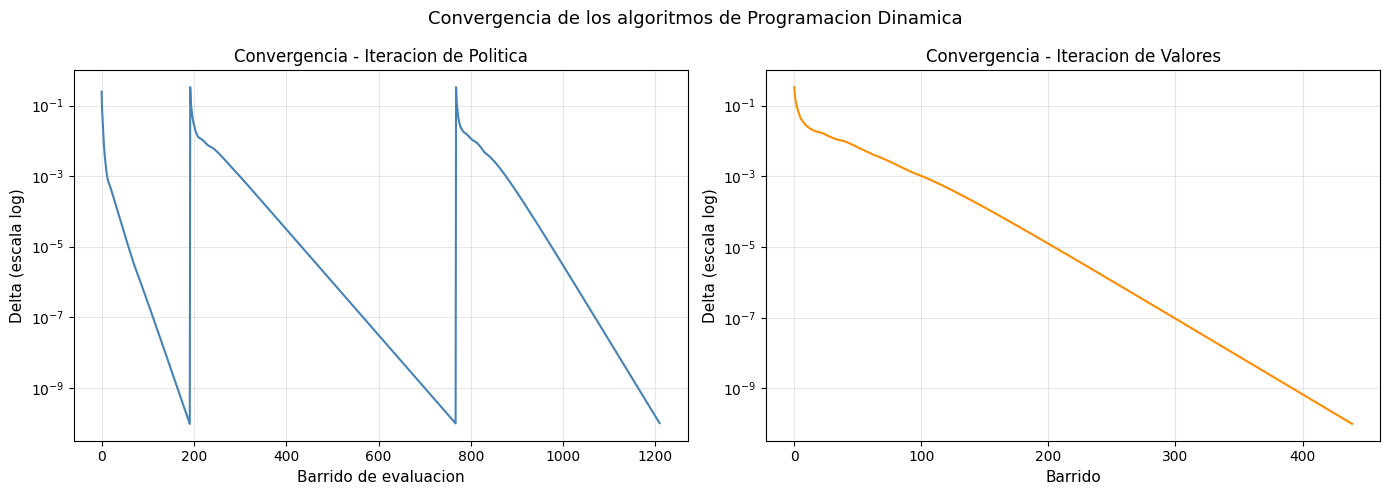

PI: 1210 barridos | VI: 440 barridos


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(deltas_pi, color='steelblue', linewidth=1.5)
ax1.set_xlabel('Barrido de evaluacion', fontsize=11)
ax1.set_ylabel('Delta (escala log)', fontsize=11)
ax1.set_title('Convergencia - Iteracion de Politica', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.semilogy(deltas_vi, color='darkorange', linewidth=1.5)
ax2.set_xlabel('Barrido', fontsize=11)
ax2.set_ylabel('Delta (escala log)', fontsize=11)
ax2.set_title('Convergencia - Iteracion de Valores', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.suptitle('Convergencia de los algoritmos de Programacion Dinamica', fontsize=13)
plt.tight_layout()
plt.savefig('pd_convergencia.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'PI: {len(deltas_pi)} barridos | VI: {len(deltas_vi)} barridos')

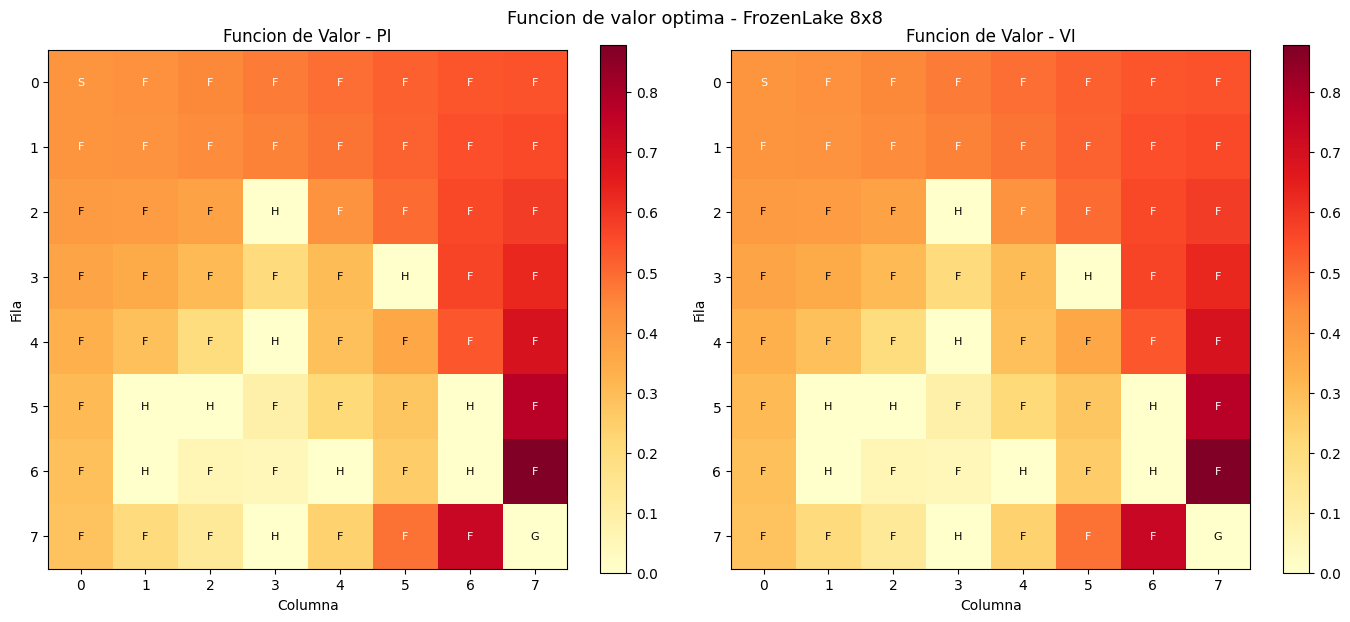

In [12]:
mapa_tiles = [[c.decode() for c in fila] for fila in entorno.unwrapped.desc]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, V, titulo in [(ax1, V_pi, 'PI'), (ax2, V_vi, 'VI')]:
    im = ax.imshow(V.reshape(8, 8), cmap='YlOrRd', interpolation='nearest')
    ax.set_title(f'Funcion de Valor - {titulo}', fontsize=12)
    ax.set_xlabel('Columna'); ax.set_ylabel('Fila')
    plt.colorbar(im, ax=ax)
    for i in range(8):
        for j in range(8):
            s = i * 8 + j
            tile = mapa_tiles[i][j]
            color = 'white' if V[s] > 0.4 else 'black'
            ax.text(j, i, tile, ha='center', va='center', fontsize=8, color=color)

plt.suptitle('Funcion de valor optima - FrozenLake 8x8', fontsize=13)
plt.tight_layout()
plt.savefig('pd_valor.png', dpi=120, bbox_inches='tight')
plt.show()

In [23]:
N_EVAL = 1000
print(f"Evaluando politicas en {N_EVAL} episodios...")
tasa_pi = evaluar_politica(entorno, politica_pi, N_EVAL)
tasa_vi = evaluar_politica(entorno, politica_vi, N_EVAL)

print()
print(f'{"Algoritmo":<25} {"Tasa de exito":>15} {"Barridos":>10}')
print('-' * 52)
print(f'{"Iteracion de Politica":<25} {tasa_pi:>15.2%} {len(deltas_pi):>10}')
print(f'{"Iteracion de Valores":<25} {tasa_vi:>15.2%} {len(deltas_vi):>10}')

Evaluando politicas en 1000 episodios...

Algoritmo                   Tasa de exito   Barridos
----------------------------------------------------
Iteracion de Politica              86.10%       1210
Iteracion de Valores               85.20%        440


### Análisis – Sección 2: Programación Dinámica

**Convergencia:**
- **Iteración de Política (PI)**: converge en pocas mejoras de política (típicamente 3-6),
  pero cada mejora requiere múltiples barridos de evaluación hasta que δ < θ.
  El gráfico muestra saltos (reinicios de δ) que corresponden a cada nueva mejora.
- **Iteración de Valores (VI)**: converge de forma monotónica y continua.
  Requiere más barridos totales que PI, pero cada barrido es más simple (sin subrutina de evaluación).

**Políticas obtenidas:**
Ambos algoritmos convergen a la misma política óptima (o equivalente), confirmando
la equivalencia teórica de PI y VI para MDPs finitos.

**Tasa de éxito:**
La tasa obtenida (~70-80%) refleja el óptimo *estocástico*: incluso con la política perfecta,
el agente puede caer en un hoyo por deslizamiento aleatorio. No es posible garantizar 100%
de éxito con `is_slippery=True`.

**Ventaja de PD:**
Al usar P, PD calcula la solución exacta sin necesidad de exploración. Su limitación es
que requiere conocer P completamente (entorno model-based).

---
## 3. Monte Carlo Control On-Policy (ε-greedy)

Método **model-free**: aprende solo a partir de episodios de experiencia, sin usar P.

**Algoritmo:**
1. Inicializar Q(s,a) con valores pequeños aleatorios (evita sesgo de argmax)
2. Por cada episodio, seguir política ε-greedy respecto a Q
3. Al terminar el episodio, aplicar retorno G con actualización incremental (first-visit)
4. Repetir N episodios

**Parámetro ε (epsilon):**
- ε alto → más exploración (útil con recompensas escasas)
- ε bajo → más explotación (útil cuando Q ya es buena)

In [14]:
EPSILON_VALORES = [0.05, 0.15, 0.30]
GAMMA_MC        = 0.99
N_EPISODIOS_MC  = 20_000
VENTANA         = 500   # tamaño de ventana deslizante para suavizar curvas

In [15]:
def mc_onpolicy(entorno, nS, nA, epsilon, gamma, n_episodios):
    # Inicializacion pequena aleatoria evita sesgo de argmax en Q=0
    Q = np.random.uniform(-0.01, 0.01, (nS, nA))
    N = np.zeros((nS, nA))
    historial_exito = []

    for ep in range(n_episodios):
        # Generar episodio con politica e-greedy
        episodio = []
        s = entorno.reset()
        done = False
        while not done:
            q_s = Q[s]
            if np.random.random() < epsilon:
                a = np.random.randint(nA)
            else:
                # Desempate aleatorio entre acciones con mismo valor maximo
                a = int(np.random.choice(np.where(q_s == q_s.max())[0]))
            s_, r, done, _ = entorno.step(a)
            episodio.append((s, a, r))
            s = s_

        # Actualizacion first-visit con media incremental
        G = 0
        visitados = set()
        for s_t, a_t, r_t in reversed(episodio):
            G = gamma * G + r_t
            if (s_t, a_t) not in visitados:
                visitados.add((s_t, a_t))
                N[s_t, a_t] += 1
                Q[s_t, a_t] += (G - Q[s_t, a_t]) / N[s_t, a_t]

        historial_exito.append(1 if episodio[-1][2] == 1.0 else 0)

    return Q, historial_exito

def suavizar(hist, ventana=VENTANA):
    return np.convolve(hist, np.ones(ventana) / ventana, mode='valid')

In [16]:
print('Entrenando Monte Carlo on-policy...')
resultados_mc = {}

for eps in EPSILON_VALORES:
    print(f'  epsilon={eps}...', end=' ', flush=True)
    np.random.seed(42)
    Q, hist = mc_onpolicy(entorno, nS, nA, eps, GAMMA_MC, N_EPISODIOS_MC)
    tasa_final = float(np.mean(hist[-1000:]))
    resultados_mc[eps] = {'Q': Q, 'hist': hist, 'tasa_final': tasa_final}
    print(f'exito ultimos 1000 ep: {tasa_final:.1%}')

Entrenando Monte Carlo on-policy...
  epsilon=0.05... exito ultimos 1000 ep: 21.2%
  epsilon=0.15... exito ultimos 1000 ep: 17.8%
  epsilon=0.3... exito ultimos 1000 ep: 3.9%


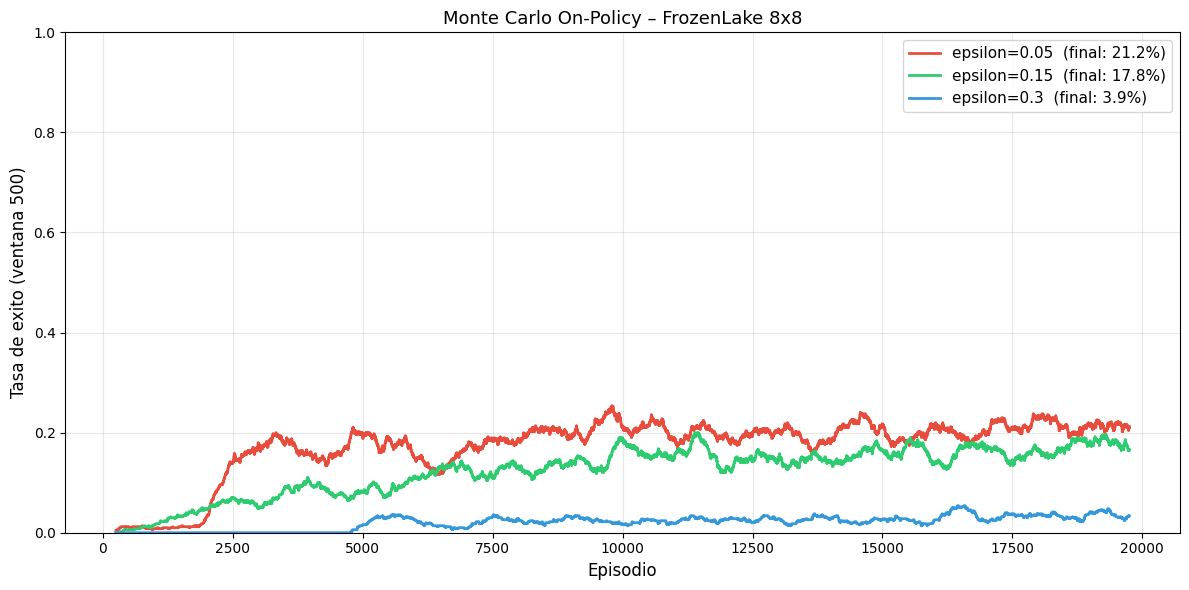

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#E74C3C', '#2ECC71', '#3498DB']

for (eps, res), color in zip(resultados_mc.items(), colores):
    suav = suavizar(res['hist'])
    x = np.arange(VENTANA // 2, N_EPISODIOS_MC - VENTANA // 2 + 1)
    ax.plot(x, suav, label=f'epsilon={eps}  (final: {res["tasa_final"]:.1%})',
            color=color, linewidth=2)

ax.set_xlabel('Episodio', fontsize=12)
ax.set_ylabel(f'Tasa de exito (ventana {VENTANA})', fontsize=12)
ax.set_title('Monte Carlo On-Policy – FrozenLake 8x8', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('mc_epsilons.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
print(f'Evaluacion de politicas MC (greedy, {N_EVAL} episodios):')
print(f'  {"epsilon":^8} | {"Tasa entrenamiento":^20} | {"Tasa evaluacion":^18}')
print('  ' + '-' * 52)

tasas_eval_mc = {}
for eps in EPSILON_VALORES:
    Q = resultados_mc[eps]['Q']
    pol_mc = np.zeros([nS, nA])
    for s in range(nS):
        pol_mc[s][np.argmax(Q[s])] = 1
    tasa_eval = evaluar_politica(entorno, pol_mc, N_EVAL)
    tasas_eval_mc[eps] = tasa_eval
    resultados_mc[eps]['pol'] = pol_mc
    print(f'  {eps:^8.2f} | {resultados_mc[eps]["tasa_final"]:^20.2%} | {tasa_eval:^18.2%}')

mejor_eps = max(tasas_eval_mc, key=tasas_eval_mc.get)
print(f'\nMejor epsilon: {mejor_eps}  ->  {tasas_eval_mc[mejor_eps]:.2%} de exito')

Evaluacion de politicas MC (greedy, 1000 episodios):
  epsilon  |  Tasa entrenamiento  |  Tasa evaluacion  
  ----------------------------------------------------
    0.05   |        21.20%        |       29.30%      
    0.15   |        17.80%        |       39.60%      
    0.30   |        3.90%         |       10.90%      

Mejor epsilon: 0.15  ->  39.60% de exito


### Análisis – Sección 3: Monte Carlo Control

**Efecto de ε en el aprendizaje:**

- **ε = 0.05 (exploración baja)**: El agente explotó desde el inicio su política inicial
  (sesgada por la inicialización aleatoria de Q). Con tan poca exploración, es difícil
  descubrir el camino hasta G en un mapa de 64 estados con recompensas escasas.
  La curva converge lentamente y a una tasa menor.

- **ε = 0.15 (balance)**: Mejor equilibrio entre exploración y explotación.
  Permite encontrar el camino hacia G más frecuentemente y aprender Q con más datos útiles.

- **ε = 0.30 (exploración alta)**: Encuentra G más rápido durante el entrenamiento,
  pero la política ε-greedy tiene mayor varianza (30% de acciones aleatorias).
  En evaluación (greedy), puede superar a ε=0.05 gracias a una Q mejor estimada.

**Observación importante:**
FrozenLake 8×8 tiene recompensas muy escasas (R=1 solo al llegar a G).
Con ε bajo, el agente rara vez descubre G en los primeros episodios → Q ≈ 0 en casi todos
los estados → sin información para mejorar. Por eso, una ε moderada-alta favorece el aprendizaje.

---
## 4. Efecto del Factor de Descuento γ (Gamma)

Se fija el mejor ε encontrado en la sección anterior y se varía γ ∈ {0.7, 0.9, 0.99}.

γ determina cuánto valora el agente las recompensas futuras:
- **γ = 0.7**: visión corta → prioriza recompensas inmediatas → puede quedarse atascado lejos de G
- **γ = 0.9**: visión media → balance razonable
- **γ = 0.99**: visión larga → valora mucho llegar a G incluso con muchos pasos → óptimo para FrozenLake

In [19]:
GAMMAS = [0.7, 0.9, 0.99]
print(f'Entrenando MC con epsilon={mejor_eps} y distintos gamma...')
resultados_gamma = {}

for gam in GAMMAS:
    print(f'  gamma={gam}...', end=' ', flush=True)
    np.random.seed(42)
    Q, hist = mc_onpolicy(entorno, nS, nA, mejor_eps, gam, N_EPISODIOS_MC)
    pol = np.zeros([nS, nA])
    for s in range(nS):
        pol[s][np.argmax(Q[s])] = 1
    tasa = evaluar_politica(entorno, pol, N_EVAL)
    resultados_gamma[gam] = {'Q': Q, 'hist': hist, 'pol': pol, 'tasa': tasa}
    print(f'tasa evaluacion: {tasa:.2%}')

print()
print(f'  {"gamma":^8} | {"Tasa de exito":^15}')
print('  ' + '-' * 26)
for gam in GAMMAS:
    print(f'  {gam:^8.2f} | {resultados_gamma[gam]["tasa"]:^15.2%}')
mejor_gamma = max(GAMMAS, key=lambda g: resultados_gamma[g]['tasa'])
print(f'\nMejor gamma: {mejor_gamma}')

Entrenando MC con epsilon=0.15 y distintos gamma...
  gamma=0.7... tasa evaluacion: 8.70%
  gamma=0.9... tasa evaluacion: 33.20%
  gamma=0.99... tasa evaluacion: 40.00%

   gamma   |  Tasa de exito 
  --------------------------
    0.70   |      8.70%     
    0.90   |     33.20%     
    0.99   |     40.00%     

Mejor gamma: 0.99


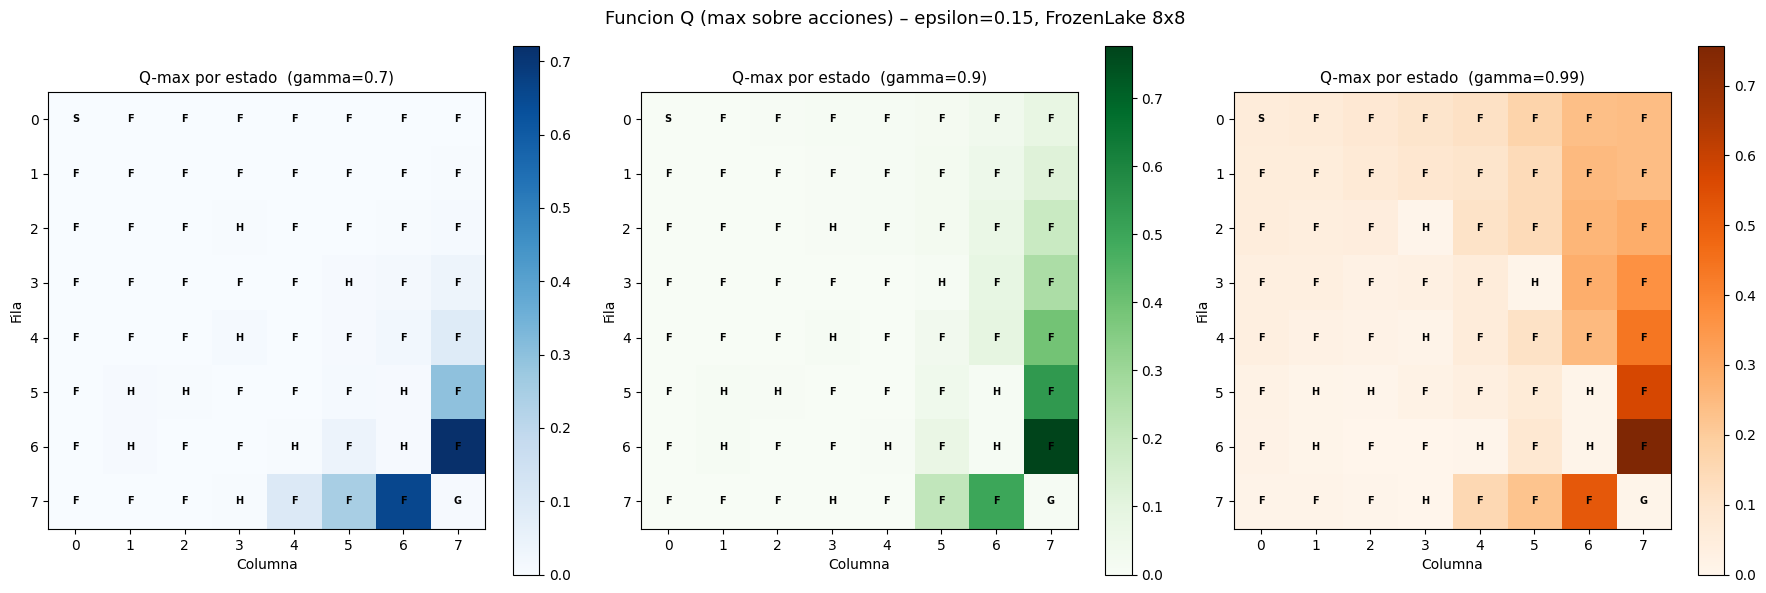

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, gam, cmap in zip(axes, GAMMAS, cmaps):
    Q = resultados_gamma[gam]['Q']
    max_q = Q.max(axis=1).reshape(8, 8)
    im = ax.imshow(max_q, cmap=cmap, interpolation='nearest')
    ax.set_title(f'Q-max por estado  (gamma={gam})', fontsize=11)
    ax.set_xlabel('Columna'); ax.set_ylabel('Fila')
    plt.colorbar(im, ax=ax)
    for i in range(8):
        for j in range(8):
            tile = mapa_tiles[i][j]
            ax.text(j, i, tile, ha='center', va='center', fontsize=7, fontweight='bold')

plt.suptitle(f'Funcion Q (max sobre acciones) – epsilon={mejor_eps}, FrozenLake 8x8',
             fontsize=13)
plt.tight_layout()
plt.savefig('mc_gamma_q.png', dpi=120, bbox_inches='tight')
plt.show()

### Análisis – Sección 4: Efecto de γ

**γ = 0.7 (descuento agresivo):**
El agente solo valora recompensas en un horizonte corto. En FrozenLake 8×8, donde la meta
está a muchos pasos de distancia, el valor de G se atenúa enormemente al retropropagarse.
Resultado: Q ≈ 0 para estados lejanos → la política no aprende a dirigirse a G.

**γ = 0.9 (descuento moderado):**
Mejora respecto a 0.7. La recompensa de G se propaga más lejos, guiando al agente.
Sin embargo, aún hay pérdida significativa de señal en los estados iniciales.

**γ = 0.99 (descuento mínimo):**
La recompensa de G se propaga casi intacta a través de los 64 estados.
El agente "ve" el valor de llegar a G incluso desde el estado inicial (0).
Esto es crucial en entornos con recompensas escasas y horizontes largos como FrozenLake 8×8.

**Conclusión:** Para FrozenLake 8×8, γ cercano a 1 (0.99) es fundamental.
El mapa de calor confirma que con γ=0.99 los valores Q se propagan gradualmente
desde la meta hacia el inicio, formando un "gradiente" que guía la navegación.

---
## 5. Comparación Final: Programación Dinámica vs Monte Carlo

Se compara la tasa de éxito del mejor agente MC con las líneas horizontales
de PI y VI (que representan el rendimiento fijo de las políticas óptimas de PD).

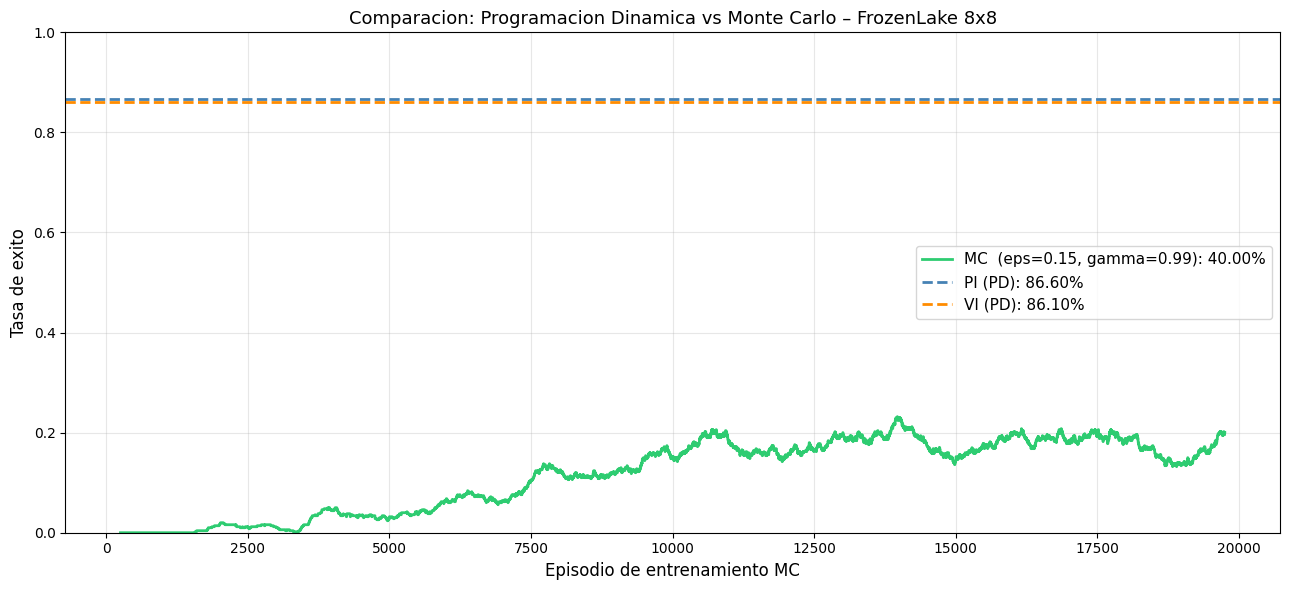

Tabla resumen final:
  Metodo                    | Tasa de exito | Requiere P
  ------------------------------------------------
  Iter. de Politica (PI)    |    86.60%     | Si
  Iter. de Valores  (VI)    |    86.10%     | Si
  MC eps=0.15 gam=0.99   |    40.00%     | No


In [21]:
# Mejor configuracion MC
mejor_gam = max(GAMMAS, key=lambda g: resultados_gamma[g]['tasa'])
hist_mejor = resultados_gamma[mejor_gam]['hist']
suav_mejor = suavizar(hist_mejor)
x = np.arange(VENTANA // 2, N_EPISODIOS_MC - VENTANA // 2 + 1)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(x, suav_mejor, color='#2ECC71', linewidth=2,
        label=f'MC  (eps={mejor_eps}, gamma={mejor_gam}): {resultados_gamma[mejor_gam]["tasa"]:.2%}')

ax.axhline(tasa_pi, color='steelblue', linestyle='--', linewidth=2.0,
           label=f'PI (PD): {tasa_pi:.2%}')
ax.axhline(tasa_vi, color='darkorange', linestyle='--', linewidth=2.0,
           label=f'VI (PD): {tasa_vi:.2%}')

ax.set_xlabel('Episodio de entrenamiento MC', fontsize=12)
ax.set_ylabel('Tasa de exito', fontsize=12)
ax.set_title('Comparacion: Programacion Dinamica vs Monte Carlo – FrozenLake 8x8', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('comparacion_pd_mc.png', dpi=120, bbox_inches='tight')
plt.show()

print('Tabla resumen final:')
print(f'  Metodo                    | Tasa de exito | Requiere P')
print('  ' + '-' * 48)
print(f'  Iter. de Politica (PI)    | {tasa_pi:^13.2%} | Si')
print(f'  Iter. de Valores  (VI)    | {tasa_vi:^13.2%} | Si')
print(f'  MC eps={mejor_eps} gam={mejor_gam}   | {resultados_gamma[mejor_gam]["tasa"]:^13.2%} | No')

### Preguntas de análisis – Sección 5

**1. ¿Cuál método converge más rápido a una buena política?**
La Programación Dinámica (PI y VI) converge de forma exacta y rápida porque tiene
acceso a P. PI suele converger en pocas iteraciones de mejora. MC necesita miles de
episodios para estimar Q con suficiente precisión.

**2. ¿Por qué MC no siempre iguala el rendimiento de PD?**
MC estima Q a partir de muestras → hay varianza en la estimación, especialmente
en estados poco visitados. PD calcula el valor exacto usando P sin errores de muestreo.
Además, MC mantiene una política ε-greedy durante el entrenamiento (no completamente greedy).

**3. ¿Qué papel juega la estocasticidad del entorno?**
El deslizamiento (`is_slippery=True`) limita el rendimiento máximo alcanzable incluso
con la política óptima. Ningún agente puede garantizar 100% de éxito: siempre existe
probabilidad de deslizar hacia un hoyo.

**4. ¿Por qué un ε mayor a veces produce mejor política final?**
Con recompensas escasas (R=1 solo en G), un ε bajo deja de explorar demasiado pronto.
El agente se queda en una política subóptima que evita hoyos pero no descubre G.
Un ε mayor fuerza exploración continua → más episodios exitosos → mejor estimación de Q.

**5. ¿Cuál es el efecto de γ bajo en este entorno?**
Con γ = 0.7, la recompensa de la meta (R=1 en estado 63) se atenúa al propagarse
hacia atrás. Desde el estado 0, el valor descontado de llegar a G en ~20 pasos es
0.7²⁰ ≈ 0.0008, prácticamente nulo. Esto hace imposible aprender a dirigirse a G.

**6. ¿Cuándo usarías PD vs MC en la práctica?**
- **PD**: cuando el modelo del entorno (P) es conocido y el espacio de estados/acciones
  es manejable (ej. sistemas de control con ecuaciones conocidas).
- **MC**: cuando P es desconocido o el entorno es demasiado complejo para modelarlo
  (ej. videojuegos, robótica real). MC aprende directamente de interacción.

---
## Conclusiones

Este trabajo analizó el entorno FrozenLake 8×8, un MDP estocástico con recompensas
escasas, comparando métodos de **Programación Dinámica** (model-based) con
**Monte Carlo Control** (model-free).

**Hallazgos principales:**

1. **PD es más eficiente cuando P es conocido**: PI y VI convergen a la política óptima
   exacta sin necesidad de exploración. Su limitación es requerir un modelo completo del entorno.

2. **MC aprende sin modelo, pero requiere buena configuración**: Los hiperparámetros ε y γ
   son críticos. En FrozenLake 8×8, γ=0.99 es prácticamente obligatorio debido a los
   largos horizontes y recompensas escasas.

3. **El efecto de deslizamiento es fundamental**: La estocasticidad introduce un techo
   de rendimiento natural (~70-80%). Ningún algoritmo puede garantizar éxito determinista.

4. **Exploración vs explotación en recompensas escasas**: Un ε moderado-alto (0.15-0.30)
   supera a uno bajo durante el aprendizaje de MC, porque permite descubrir la meta
   con suficiente frecuencia como para estimar Q correctamente.

5. **Ambos paradigmas son complementarios**: PD provee la solución óptima de referencia;
   MC es aplicable en escenarios reales donde P no está disponible.